In [14]:
from pathlib import Path
from functools import namedtuple

import pandas as pd
import seaborn as sns

sns.set_context("talk")
import tqdm.auto as tqdm

from dti import data
from dti.utils import scaffold_split
from dti.constants import ACT, ASSAY

In [2]:
data_path = Path("..") / "data" / "raw"
Row = namedtuple("Row", ["overlap", "correlation"])

# Assay overlap in scaffold splits

In [3]:
def sample_assay_overlap(
    df: pd.DataFrame, seed: int, fillna: bool = False, progress: bool = False
):
    df_train, df_test = scaffold_split(df, seed=seed, progress=progress)
    overlap = df_test[ASSAY].isin(df_train[ASSAY]).mean()
    predictor = df_train.groupby(ASSAY)[[ACT]].agg("mean")
    df_test = df_test.join(
        predictor.rename(columns={ACT: "assay_mean"}), on=ASSAY, how="left"
    )
    if fillna:
        df_test.fillna(value=df_train[ACT].mean(), inplace=True)
    corr = df_test.corr(numeric_only=True).loc["assay_mean", "activity_value"]

    return overlap, corr

sample overlap:   0%|          | 0/500 [00:00<?, ?it/s]

scaffold:   0%|          | 0/179982 [00:00<?, ?it/s]

overlap        0.895500
correlation    0.696597
dtype: float64

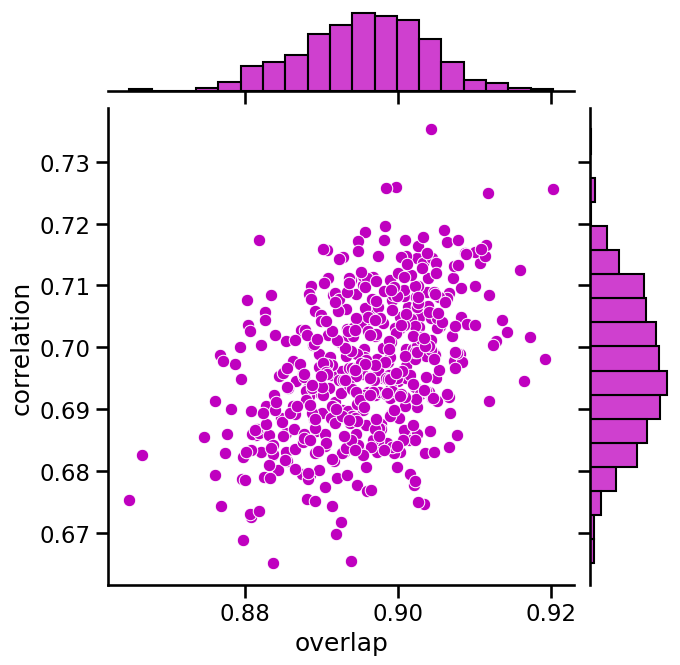

In [4]:
df = data.load_kinodata(data_path / "activities-chembl33_v0.5.csv")
dcorr = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed, fillna=True, progress=seed == 0))
        for seed in tqdm.tqdm(range(500), desc="sample overlap")
    ]
)
sns.jointplot(dcorr, x="overlap", y="correlation", kind="scatter", color="m", height=7)
dcorr.mean()

  0%|          | 0/500 [00:00<?, ?it/s]

scaffold:   0%|          | 0/838155 [00:00<?, ?it/s]

overlap        0.931689
correlation    0.734168
dtype: float64

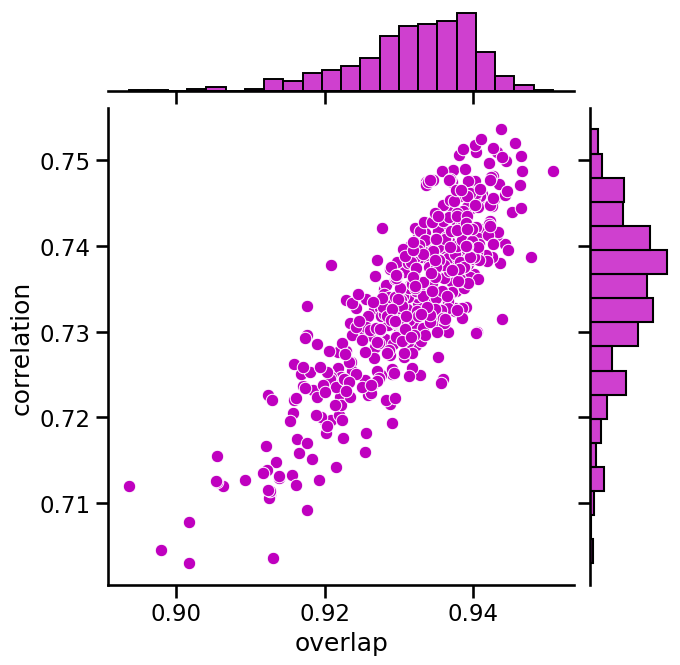

In [18]:
df = data.load_landrum(data_path / "omnivore.csv")
dcorr = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed, fillna=True, progress=seed == 0))
        for seed in tqdm.tqdm(range(500))
    ]
)
ax = sns.jointplot(
    dcorr, x="overlap", y="correlation", kind="scatter", color="m", height=7
)
dcorr.mean()

  0%|          | 0/500 [00:00<?, ?it/s]

scaffold:   0%|          | 0/259823 [00:00<?, ?it/s]

overlap        0.972077
correlation    0.730866
dtype: float64

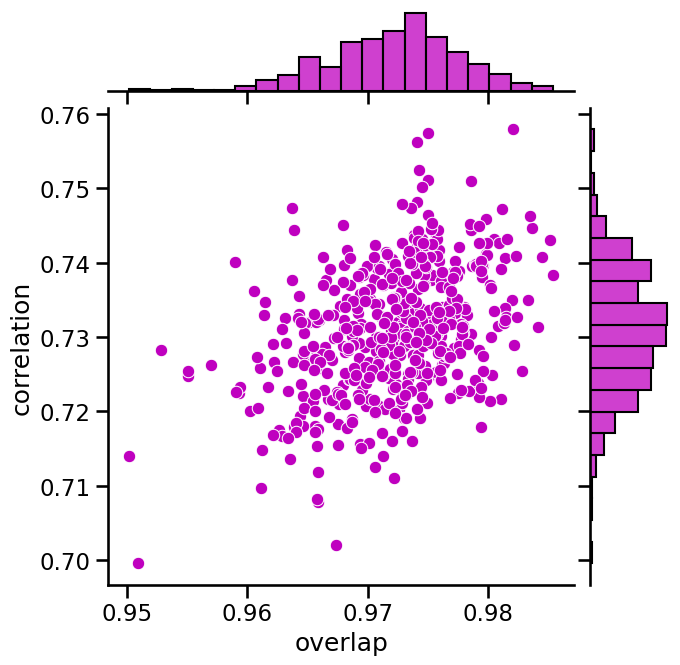

In [19]:
df = data.load_landrum(data_path / "landrum.csv")
dcorr = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed, fillna=True, progress=seed == 0))
        for seed in tqdm.tqdm(range(500))
    ]
)
sns.jointplot(dcorr, x="overlap", y="correlation", kind="scatter", color="m", height=7)
dcorr.mean()

  0%|          | 0/500 [00:00<?, ?it/s]

scaffold:   0%|          | 0/49741 [00:00<?, ?it/s]

overlap        0.976206
correlation    0.327885
dtype: float64

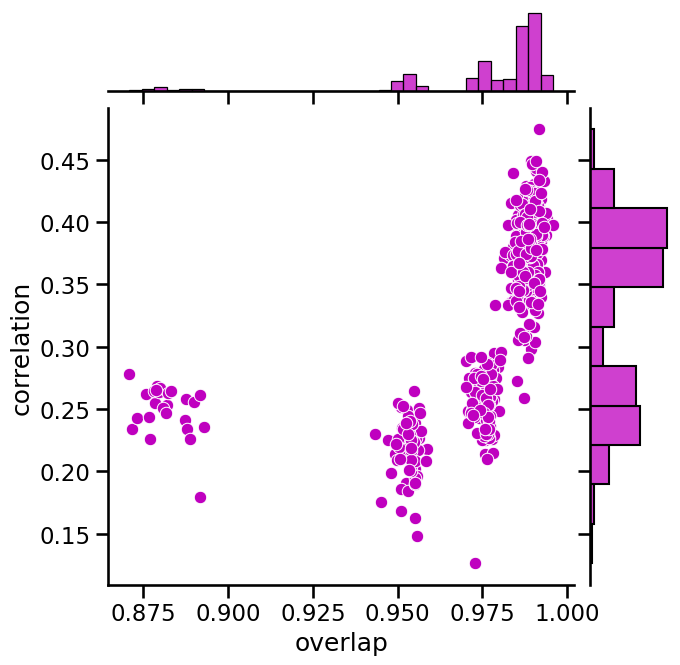

In [22]:
df = data.load_nci(data_path / "atcc.csv.bkp")
dcorr = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed, fillna=True, progress=seed == 0))
        for seed in tqdm.tqdm(range(500))
    ]
)
sns.jointplot(dcorr, x="overlap", y="correlation", kind="scatter", color="m", height=7)
dcorr.mean()

  0%|          | 0/500 [00:00<?, ?it/s]

scaffold:   0%|          | 0/48186 [00:00<?, ?it/s]

overlap        0.97621
correlation    0.32206
dtype: float64

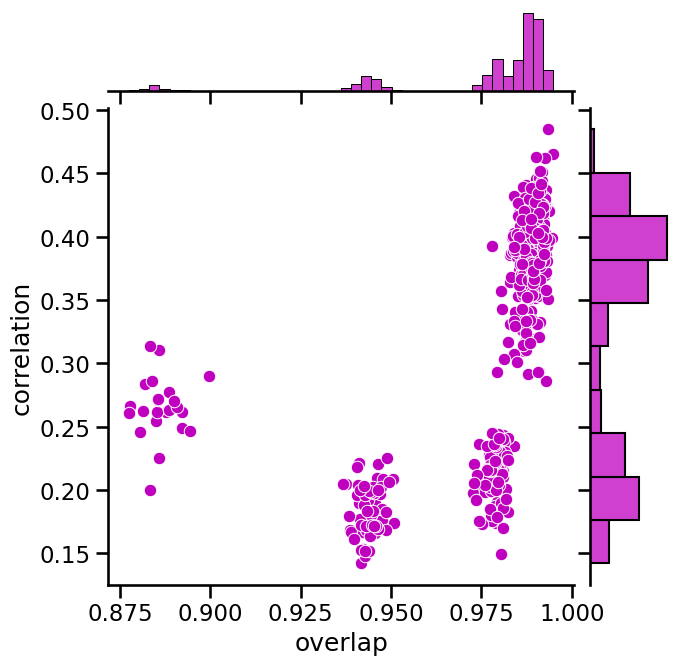

In [21]:
df = data.load_nci(data_path / "ovcar.csv")
dcorr = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed, fillna=True, progress=seed == 0))
        for seed in tqdm.tqdm(range(500))
    ]
)
sns.jointplot(dcorr, x="overlap", y="correlation", kind="scatter", color="m", height=7)
dcorr.mean()